In [1]:
import pandas as pd

df = pd.read_excel("online_retail_II.xlsx")

df.columns = df.columns.str.strip()
df.rename(columns={'Customer ID': 'CustomerID', 'Price': 'UnitPrice'}, inplace=True)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

In [2]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

cohort = df.groupby('CustomerID')['InvoiceDate'].min().dt.to_period('M')
df['CohortMonth'] = df['CustomerID'].map(cohort)

In [3]:
df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

In [4]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

In [5]:
retention_matrix = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)
retention_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12,1.0,0.375120,0.342584,0.427751,0.392344,0.390431,0.390431,0.357895,0.339713,0.375120,0.432536,0.495694,0.248804
2010-01,1.0,0.218274,0.302030,0.304569,0.279188,0.291878,0.266497,0.230964,0.289340,0.340102,0.309645,0.093909,NaN
2010-02,1.0,0.300275,0.225895,0.303030,0.256198,0.209366,0.217631,0.283747,0.275482,0.292011,0.088154,NaN,NaN
2010-03,1.0,0.217890,0.259174,0.236239,0.229358,0.199541,0.240826,0.298165,0.288991,0.082569,NaN,NaN,NaN
2010-04,1.0,0.230241,0.199313,0.161512,0.185567,0.230241,0.271478,0.261168,0.075601,NaN,NaN,NaN,NaN
2010-05,1.0,0.192913,0.177165,0.192913,0.188976,0.259843,0.220472,0.086614,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.215613,0.197026,0.204461,0.230483,0.282528,0.074349,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.207650,0.202186,0.284153,0.300546,0.114754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.246835,0.316456,0.322785,0.126582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


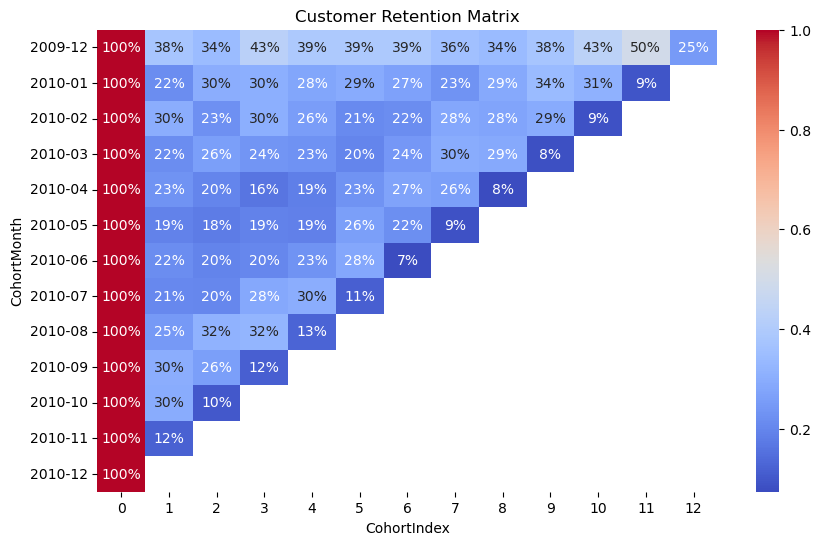

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(retention_matrix, annot=True, fmt=".0%", cmap="coolwarm")

plt.title("Customer Retention Matrix")
plt.show()